### The purpose of this notebook is to reproduce figure 2 from the text. 

First, load in modules.

In [126]:
import os, sys
import time
import csv
import tqdm.notebook as tqdm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
from scipy.optimize import curve_fit
from sklearn import linear_model
from sklearn.linear_model import Lasso
from sklearn.decomposition import PCA
import warnings
from sklearn.metrics import r2_score
from sklearn.exceptions import ConvergenceWarning
import tqdm.notebook as tqdm

from mgsa.io import samples_from_soils, get_function, get_data
from mgsa.modeling import Model
from mgsa.helpers import plot, plot10
from sklearn.preprocessing import MinMaxScaler, StandardScaler

from scipy.cluster.hierarchy import linkage, dendrogram, fcluster, optimal_leaf_ordering
from scipy.spatial.distance import pdist
from matplotlib.colors import to_hex

### PART 1: repeat clustering steps from fig1.ipynb to find groups. 

#### Load in data, then perform hierarchical clustering. 

In [127]:
KO = 'K00370'
map = '09'
Drug = 'None'

complete_ids = pd.read_csv(f'../out/aaseqs/{KO}/long_complete_orf_ids.txt', header = None)
complete_ids = complete_ids.values
print(complete_ids.shape, complete_ids.dtype)

all_ids = pd.read_csv(f'../out/orf_ids/cluster_ids_{map}_{KO}.tsv', sep = '\t', header=None)

map = pd.read_csv(f'../out/aaseqs/{KO}/incomplete_to_complete_seq_mapping.tsv', sep = '\t')
map = map.values
print(map[:,1].shape, map[:,1].dtype)
print(map)

T0data = np.zeros((len(complete_ids), 20))
T9data = np.zeros((len(complete_ids), 10, 11))

for i, id in enumerate(complete_ids):
    got_data = get_data(id, drug = Drug, KO=KO)
    T0data[i] += got_data[0]
    T9data[i] += got_data[1]

print(T9data[:,:,1].shape)

for i, id in enumerate(map[:,0]):
    complete_id = map[i, 1]
    idx = np.where(complete_ids == complete_id)[0][0]
    got_data = get_data(id, drug = Drug)
    T0data[idx] += got_data[0]
    T9data[idx] += got_data[1]






(57, 1) object
(451,) object
[['Soil11.scaffold_669406189_c1_1' 'Soil9.scaffold_209032411_c1_3'
  5.449392712550607]
 ['Soil11.scaffold_168782194_c1_1' 'Soil9.scaffold_209032411_c1_3'
  4.704142011834319]
 ['Soil11.scaffold_603781636_c1_1' 'Soil15.scaffold_116822102_c1_19'
  4.966360856269113]
 ...
 ['T0.scaffold_685359621_c1_1' 'Soil6.scaffold_312871021_c1_4'
  4.787878787878788]
 ['T0.scaffold_925671294_c1_1' 'Soil17.scaffold_274056314_c1_61'
  4.8262108262108265]
 ['T0.scaffold_409096425_c1_1' 'Soil5.scaffold_183283646_c1_24'
  5.014767932489452]]
(57, 10)


In [128]:



strc_data = pd.read_csv(f'../out/structure_analysis/{KO}/structure_metrics_{KO}.tsv', sep='\t')
strc_data = strc_data.values
strc_data = strc_data[:, 1:]#remove the first column (orf names)

scaler = MinMaxScaler()
strc_data = scaler.fit_transform(strc_data)


data_abs = T0data
T0data = T0data / T0data.sum(axis = 1, keepdims=True)
T0data = np.nan_to_num(T0data, nan = 0)

data = T0data 
for i in range(10):
    T9temp = T9data[:,i,:]
    data_abs = np.hstack((data_abs, T9temp))
    T9temp = T9temp / T9temp.sum(axis = 1, keepdims=True)
    T9temp = np.nan_to_num(T9temp, nan = 0)
    data = np.hstack((data, T9temp))
    

pairwise_data = np.load(f'../out/aaseqs/{KO}/long_complete_pwalignment_scores.npy')
print(pairwise_data)
pairwise_data = scaler.fit_transform(pairwise_data)
np.savetxt(f"../out/K00370abundances/complete_abundances_nrm.tsv", data, delimiter = '\t', fmt = '%0.6f')
np.savetxt(f"../out/K00370abundances/complete_abundances_abs.tsv", data_abs, delimiter = '\t', fmt = '%0.6f')
data = np.hstack((data, pairwise_data))
data_abs = np.hstack((data_abs, pairwise_data))

a = 0.5 #chose how to weight phenotype and genotype
weights = np.concatenate([
    np.full(20, a**2/np.sqrt(130)),    
    np.full(110, a**2/np.sqrt(130)) ,
    np.full(57, (np.sqrt(1 - a**2))/np.sqrt(57))
])

weighted_data = data * weights 


[[6505. 2888. 2987. ... 2950. 5906. 2973.]
 [2888. 6662. 3282. ... 4721. 2914. 3331.]
 [2987. 3282. 6539. ... 3258. 3002. 4512.]
 ...
 [2950. 4721. 3258. ... 6743. 2975. 3230.]
 [5906. 2914. 3002. ... 2975. 6519. 3032.]
 [2973. 3331. 4512. ... 3230. 3032. 6674.]]


/var/folders/_1/szp4571s76d__d0kyyc1stgc0000gn/T/ipykernel_71750/775824698.py:10: RuntimeWarning: invalid value encountered in divide
  T0data = T0data / T0data.sum(axis = 1, keepdims=True)
/var/folders/_1/szp4571s76d__d0kyyc1stgc0000gn/T/ipykernel_71750/775824698.py:17: RuntimeWarning: invalid value encountered in divide
  T9temp = T9temp / T9temp.sum(axis = 1, keepdims=True)


### Perform clustering and plot results

[28, 14, 3, 45, 25, 26, 37, 53, 11, 19, 15, 54, 4, 21, 6, 1, 44, 5, 52, 0, 27, 55, 10, 49, 20, 35, 31, 33, 39, 18, 30, 8, 17, 41, 36, 12, 13, 7, 34, 23, 38, 9, 2, 22, 51, 40, 32, 29, 24, 47, 42, 56, 50, 46, 43, 16, 48]


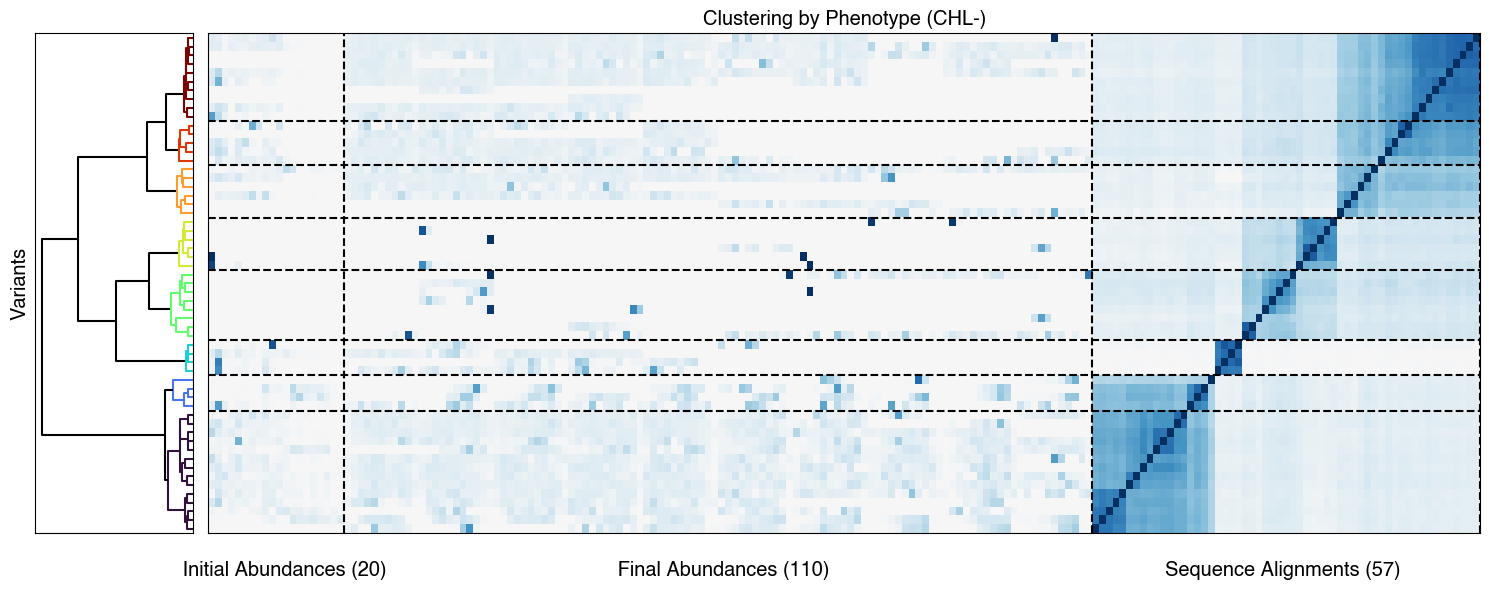

In [129]:



Z = linkage(weighted_data, method='ward', metric='euclidean')
Z_optimal = optimal_leaf_ordering(Z, pdist(data, metric='euclidean'))

n_clusters = 8
clusters = fcluster(Z_optimal, t=n_clusters, criterion='maxclust')

dendro = dendrogram(Z_optimal, no_plot=True)
leaf_indices = dendro['leaves']

idx_to_cluster = {i: clusters[i] for i in range(len(clusters))}


next_node = len(clusters)
node_to_cluster = {}

for i, (left, right, _, _) in enumerate(Z_optimal):
    left, right = int(left), int(right)
    left_cluster = idx_to_cluster.get(left, node_to_cluster.get(left, -1))
    right_cluster = idx_to_cluster.get(right, node_to_cluster.get(right, -1))
    if left_cluster == right_cluster and left_cluster != -1:
        node_to_cluster[next_node] = left_cluster
    next_node += 1
    
    

#cluster_colors = ['#1f77b4', "#9729E0", "#610a70", "#210bcb"]
cmap = plt.cm.turbo # Or any other colormap (e.g., 'viridis', 'plasma')
cluster_colors = [to_hex(cmap(i)) for i in np.linspace(0, 1, n_clusters)]

def color_func(link_idx):
    cluster_id = node_to_cluster.get(link_idx, -1)
    if cluster_id != -1 and cluster_id <= len(cluster_colors):
        return cluster_colors[cluster_id - 1]
    return "#000000"  # default color for unclustered links


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6), gridspec_kw={'width_ratios': [0.5, 4]})

dendrogram(Z_optimal,
           orientation='left',
           ax=ax1,
           color_threshold=max(Z_optimal[-n_clusters+1, 2], 0.1),
           link_color_func=color_func,
           above_threshold_color='k')

ax1.set_title('')
ax1.set_xlabel('')
ax1.set_ylabel('Variants', fontname='Helvetica', fontsize = 'x-large')
ax1.set_xticks([])
ax1.set_yticks([])
ax1.tick_params(left=False, bottom=False)

data = np.array(data)

rearranged_data = data[leaf_indices]
col_leaf_indices = leaf_indices+130*np.ones(57, dtype = int)
rearranged_data[:, 130:187] = rearranged_data[:, col_leaf_indices]

im = ax2.imshow(rearranged_data, aspect='auto', cmap='RdBu',
                interpolation='nearest', origin='lower', vmin = -1, vmax = 1)
#plt.colorbar(im, ax=ax2)


boundaries = np.where(np.diff(clusters[leaf_indices]))[0]
for b in boundaries:
    ax2.axhline(b + 0.5, color='black', linestyle='--')
    
ax2.axvline(19.5, color='black', linestyle='--')
ax2.axvline(129.5, color='black', linestyle='--')
ax2.axvline(186.5, color='black', linestyle='--')
ax2.set_xticks([])

ax2.set_title('Clustering by Phenotype (CHL-)', fontname='Helvetica', fontsize = 'x-large')
ax2.set_xlabel('\n Initial Abundances (20) \t \t \t \t \t \t \t \t \t \t \t \t \t \t \t \t \t        Final Abundances (110)   \t \t \t \t \t  \t \t \t \t  \t \t \t \t \t \t \t \t \t \t \t \t \t \t \t \t \t \t \t Sequence Alignments (57) \t \t \t \t \t \t \t \t \t \t', fontname='Helvetica', fontsize = 'x-large')

#ax2.set_ylabel('Variants', fontname='Helvetica', fontsize='x-large')

ax2.set_yticks([])
ax2.set_yticks([])
plt.tight_layout()

print(leaf_indices)
    
plt.show()

Next, save group membership IDs for each ORF. 

In [130]:
orf_list = pd.read_csv('../out/aaseqs/K00370/long_complete_orf_ids.txt', header=None)
orf_list = orf_list.values
orf_list = [orf[0] for orf in orf_list]

clusters = list(zip(orf_list, clusters))

with open("../out/groups/assignments_K00370.tsv", 'w') as f:
    for row in clusters:
        f.write(f"{row[0]} {row[1]}\n")
    


### PART 2: Curvefit to find r_A (CHL+) across the pH phasespace

In [131]:
def timestep(rhs, y_n, params, dt):
    """RK4 timestep
    
    Args:
        rhs (callable): Right hand side derivative function dy/condt. Should return
            an array of length d.
            
        y_n (np.ndarray[float]): Current state. Length d.
        params (list): variable length list of parameters.
        dt (float): stepsize.
    
    Returns:
        (np.ndarray) array of length d, the updated state, using RK4.
    """
    k_1 = rhs(y_n, params)
    k_2 = rhs(y_n + dt*k_1/2, params)
    k_3 = rhs(y_n + dt*k_2/2, params)
    k_4 = rhs(y_n + dt*k_3, params)
    y_new = y_n + (dt/6) * (k_1 + 2*k_2 + 2*k_3 + k_4)
    return y_new


def simulate(rhs, y0, params, dt, T):
    """Simulate an ODE from an initial condition over a specified interval.
    
    Args:
        rhs (callable): Right hand side derivative function dy/dt. Should return
            an array of length d.
        y0 (np.ndarray[float]): Initial condition. Length d.
        params (list): variable length list of parameters.
        dt (float): stepsize.
        T (float): final time.
    
    Returns:
        (np.ndarray) Array of shape (d, N). The state history over the interval.
    """
    N = int(T/dt)
    d = len(y0)
    ys = np.zeros([d, N])
    ys[:,0] = y0
    y = ys[:,0]
    for i in range(N-1):
        y_new = timestep(rhs, y, params, dt)
        ys[:, i + 1] = y_new
        y = y_new
    return ys

In [132]:
def RHS(y, params):
    A = y
    r, K_A, x_0 = params

    dA = -r*x_0*A/(K_A + A)
    
    dydt = np.array(dA)
    return dydt



native:   0%|          | 0/10 [00:00<?, ?it/s]

pert:   0%|          | 0/10 [00:00<?, ?it/s]

pert:   0%|          | 0/10 [00:00<?, ?it/s]

pert:   0%|          | 0/10 [00:00<?, ?it/s]

pert:   0%|          | 0/10 [00:00<?, ?it/s]

...

pert:   0%|          | 0/10 [00:00<?, ?it/s]

pert:   0%|          | 0/10 [00:00<?, ?it/s]

pert:   0%|          | 0/10 [00:00<?, ?it/s]

pert:   0%|          | 0/10 [00:00<?, ?it/s]

pert:   0%|          | 0/10 [00:00<?, ?it/s]

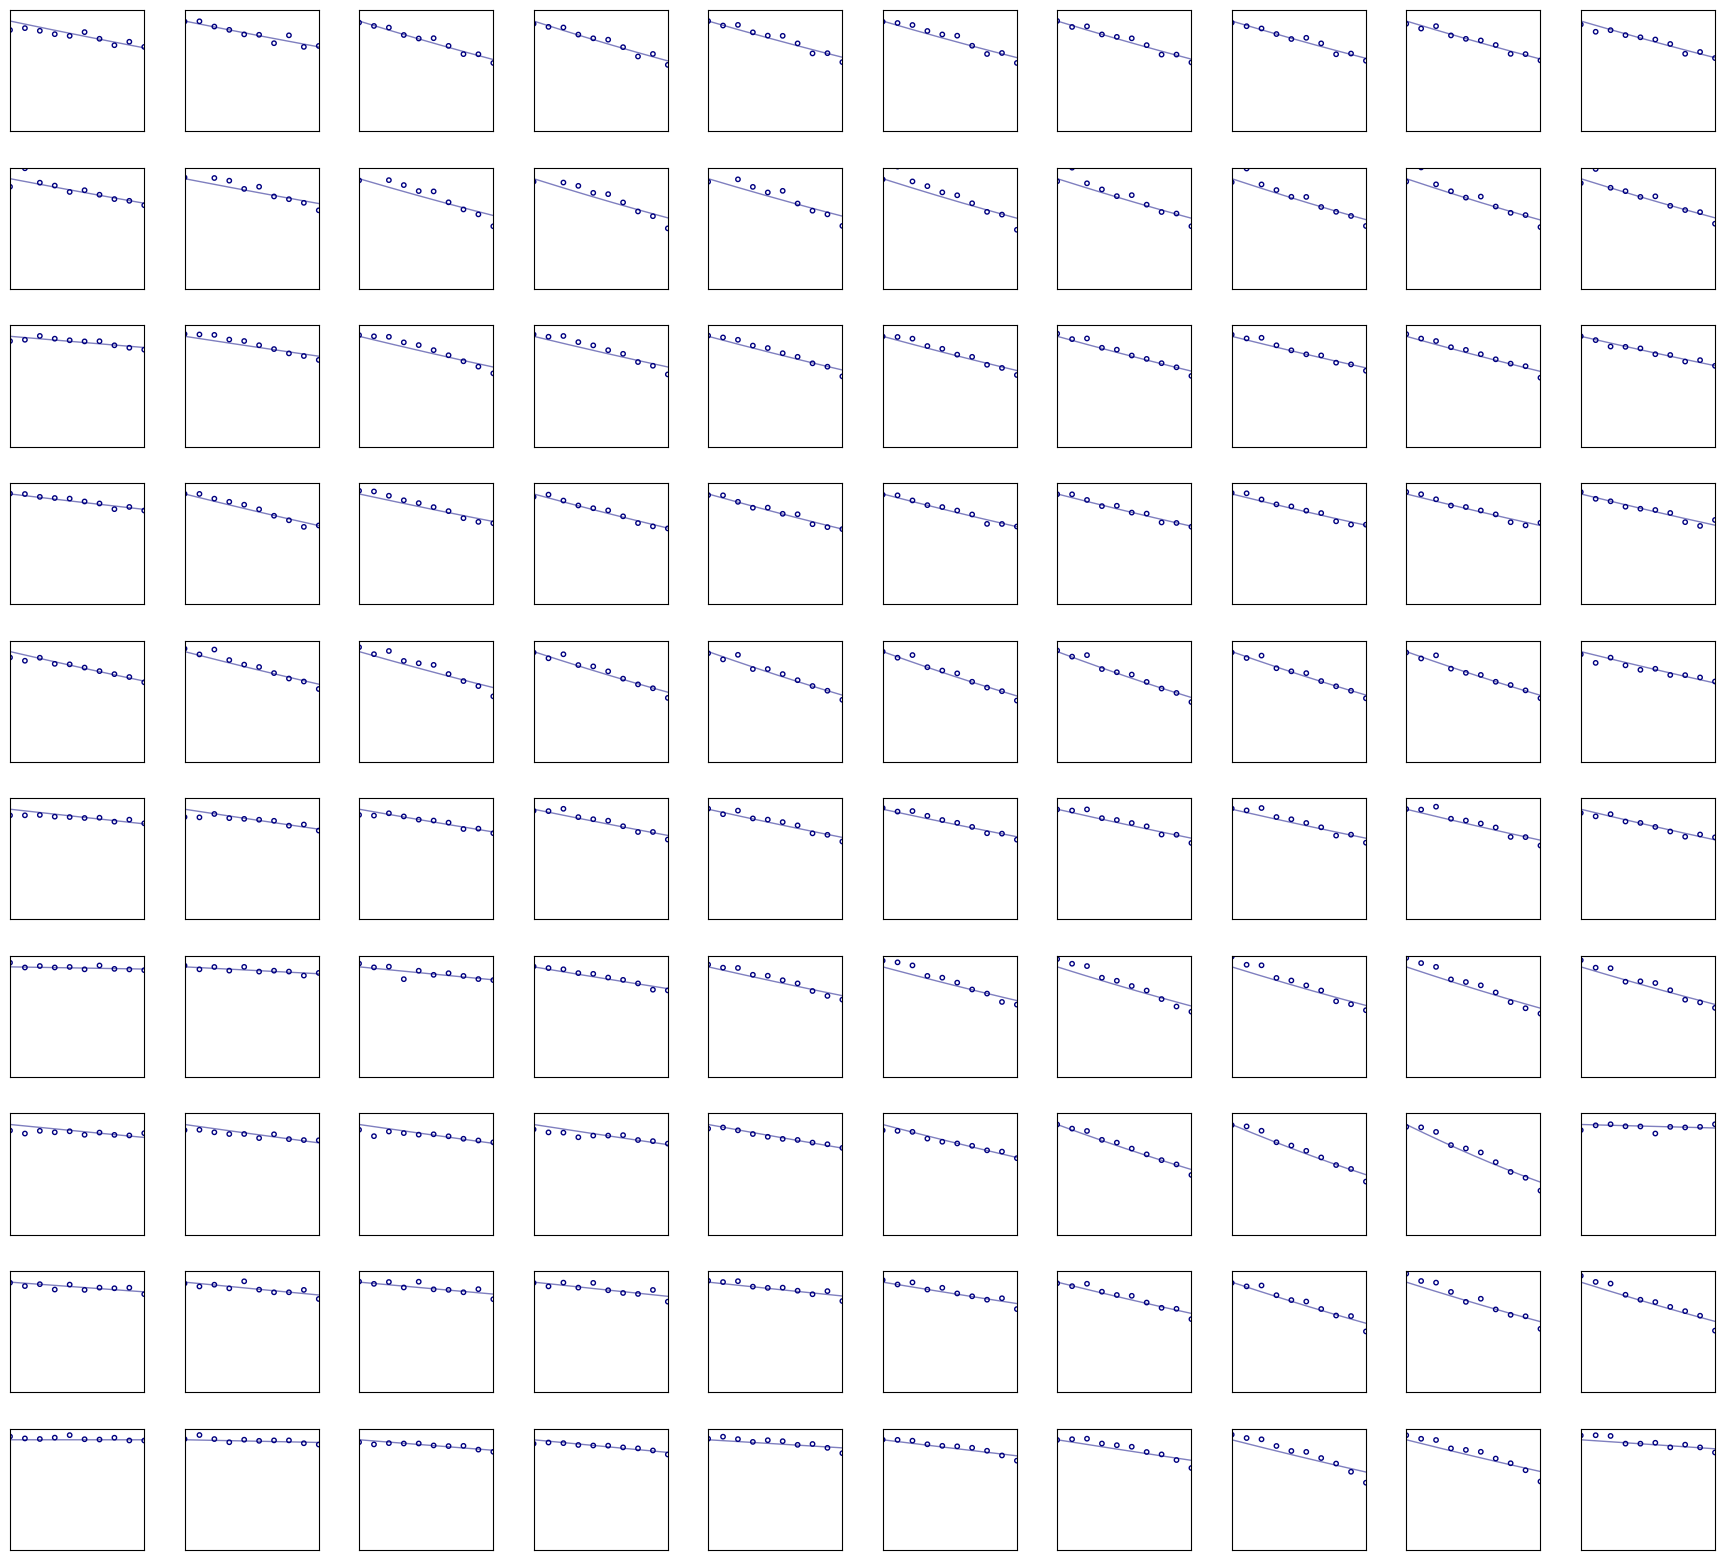

In [133]:

fig, axs = plt.subplots(10, 10, figsize=(22, 20))
plt.subplots_adjust(hspace=0.3, wspace=0.3)


t_data = np.linspace(0, 19, 20)
soils = ['Soil3', 'Soil5', 'Soil6', 'Soil9', 'Soil11', 'Soil12', 'Soil14', 
         'Soil15', 'Soil16', 'Soil17']

A_0 = 2
K_A = 1
dt = 0.05
T = 9

x_0 = 0.1

N = int(T/dt)

param_values = np.zeros((10,10))

for native in tqdm.trange(10, desc = 'native'): 
    for pert in tqdm.trange(10, desc = 'pert'):  
        

        sample = samples_from_soils(soils[native])[pert]
        
        function = get_function(sample, drug = 'CHL')
        A_data_drug = np.zeros(10)
        for i in range(3):
            A_data_drug += function[i]
        y_data_drug = A_data_drug/3
        
        
        def model_drug(t, r):
            indices = np.linspace(0, int(9/dt-1), 10).astype(int)

            y0 = np.array([A_0])
            params = [r, K_A, x_0]
            A = simulate(RHS, y0, params, dt, T)[0]
            A_out = A[indices]
            return A_out
        
        
        initial_guess = [0.1]
        bounds = ([0.001], [10])
        
        popt, pcov = curve_fit(model_drug, t_data, y_data_drug, 
                              p0=initial_guess, 
                              bounds=bounds,
                              maxfev=100000)
        
        param_values[native, pert] = popt[0]
        r = popt[0]
        
        y0 = np.array([A_0])
        params = [r, K_A, x_0]
        A = simulate(RHS, y0, params, dt, T)[0]

        t = np.linspace(0, 9, N)
        t_scatter = np.linspace(0, 9, 10)
        
        ax = axs[native, pert]
        ax.plot(t, A, color='navy', alpha=0.5, linewidth=1)
        ax.scatter(t_scatter, y_data_drug, color='navy', s=10, facecolors = 'none')
        
        
        ax.set_xlim(0, 9)
        ax.set_ylim(0,2.2)
        
        ax.set_xticks([])
        ax.set_yticks([])
        

plt.show()

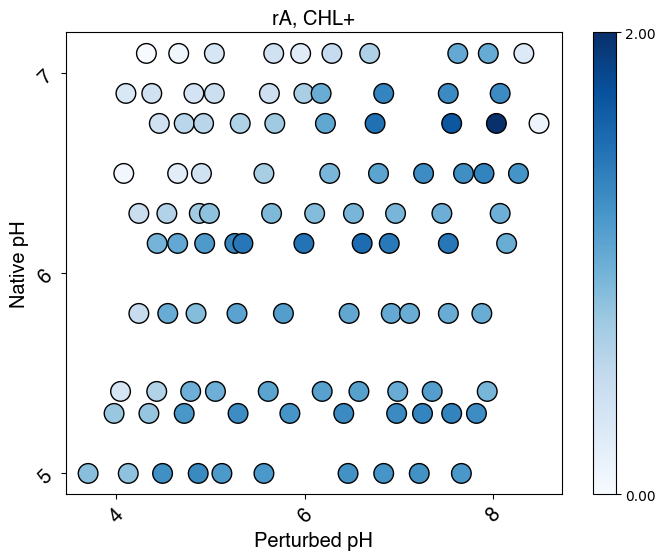

<Axes: title={'center': 'rA, CHL+'}, xlabel='Perturbed pH', ylabel='Native pH'>

In [134]:
Y = param_values
plot10(param_values, 'rA, CHL+')

### PART 3: Compute mutually information, both locally across the phasespace. 

In [135]:
#functions are stored in mgsa.information
from mgsa.information import information_2D, pairwise_cmi_analysis, get_info, get_info_control, native_pH, get_entropy, normalized_info_2D

soils = ['Soil3', 'Soil5', 'Soil6', 'Soil9', 'Soil11', 'Soil12', 'Soil14', 'Soil15', 'Soil16', 'Soil17']

native = np.zeros(len(soils))
for i, soil in enumerate(soils):
    native[i] = native_pH(soil)

### Load in groups and their abundances. 

In [136]:
NARG_INFO = {
    "KO": "K00370",
    "ORF_GROUPS_FPATH": "../out/groups/assignments_K00370.tsv"
}

pH_matrix = pd.read_csv('../out/pH_matrix.tsv', sep = '\t', header=None).values

native_matrix = np.zeros((10,10))

NATIVE_IDXS = [2, 4, 5, 8, 10, 11, 13, 14, 15, 16]
NATIVE_PHS = np.array([5.0, 5.3, 5.41, 5.8, 6.15, 6.3, 6.5, 6.75, 6.9,  7.1])

for nat in range(10):
    for pert in range(10):
        native_matrix[nat, pert] = NATIVE_PHS[nat]

OUTDIR = "../out/model_regression/nar"
IMGDIR = f"{OUTDIR}/images"
os.makedirs(OUTDIR, exist_ok=True)
os.makedirs(IMGDIR, exist_ok=True)

def texify(param_name):
    return {
        "gamma_A": "\\gamma_{{A}}", 
        "gamma_I": "\\gamma_{{I}}", 
        "r_A": "r_{{A}}", 
        "r_I1": "r_{{I1}}", 
        "r_I2": "r_{{I2}}", 
        "K_A": "K_{{A}}", 
        "K_I": "K_{{I}}", 
        "mu": "\\mu", 
    }[param_name]

t_data_drug = np.linspace(0, 19, 20)


def load_orf_groups(fpath) -> tuple[dict[int:str], np.ndarray[int]]:
    groups = {}
    idxs = []
    with open(fpath, "r") as f:
        csvreader = csv.reader(f, delimiter=" ")
        for row in csvreader:  # process each row
            orf = row[0]
            gidx = int(row[1])
            if gidx in groups:
                groups[gidx].append(orf)
            else:
                groups[gidx] = [orf]
                idxs.append(gidx)
    return groups, np.sort(idxs)

##############################################################################
##  Collect narG data

# Load ORF groups for narG
groups, group_idxs = load_orf_groups(NARG_INFO["ORF_GROUPS_FPATH"])
total = 0
for gidx in group_idxs:
    group = groups[gidx]
    n = len(group)
    print(f"Group {gidx}: {n} ORFs")
    total += n
print(f"  Total: {total}")

# Aggregate T0 and T9 expression data in the CHL+ and CHL- conditions
gidx2exp_chl_pos_t0 = {gidx: [] for gidx in group_idxs}
gidx2exp_chl_pos_t9 = {gidx: [] for gidx in group_idxs}
gidx2exp_chl_neg_t0 = {gidx: [] for gidx in group_idxs}
gidx2exp_chl_neg_t9 = {gidx: [] for gidx in group_idxs}
for gidx in group_idxs:
    group = groups[gidx]
    for i, orf in enumerate(group):
        data_chl_pos_t0, data_chl_pos_t9 = get_data(
            orf, 
            DATDIR='../out', 
            KO=NARG_INFO["KO"], 
            drug='CHL', 
            map='09',
        )
        data_chl_neg_t0, data_chl_neg_t9 = get_data(
            orf, 
            DATDIR='../out', 
            KO=NARG_INFO["KO"], 
            drug='None', 
            map='09',
        )
        
        data_chl_pos_t9 = [row[:10] for row in data_chl_pos_t9]
        data_chl_neg_t9 = [row[:10] for row in data_chl_neg_t9]
        
        # Subset T0 samples to those of interest
        data_chl_pos_t0 = data_chl_pos_t0[NATIVE_IDXS]
        data_chl_neg_t0 = data_chl_neg_t0[NATIVE_IDXS]

        gidx2exp_chl_pos_t0[gidx].append(data_chl_pos_t0)
        gidx2exp_chl_pos_t9[gidx].append(data_chl_pos_t9)
        gidx2exp_chl_neg_t0[gidx].append(data_chl_neg_t0)
        gidx2exp_chl_neg_t9[gidx].append(data_chl_neg_t9)

    # Sum the expression data in each group
    gidx2exp_chl_pos_t0[gidx] = np.sum(gidx2exp_chl_pos_t0[gidx], axis=0)
    gidx2exp_chl_pos_t9[gidx] = np.sum(gidx2exp_chl_pos_t9[gidx], axis=0)
    gidx2exp_chl_neg_t0[gidx] = np.sum(gidx2exp_chl_neg_t0[gidx], axis=0)
    gidx2exp_chl_neg_t9[gidx] = np.sum(gidx2exp_chl_neg_t9[gidx], axis=0)

# Check lengths are correct
for gidx in group_idxs:
    assert gidx2exp_chl_pos_t0[gidx].shape == (10,), "Wrong shape for t0 pos"
    assert gidx2exp_chl_pos_t9[gidx].shape == (10,10), "Wrong shape for t9 pos"
    assert gidx2exp_chl_neg_t0[gidx].shape == (10,), "Wrong shape for t0 neg"
    assert gidx2exp_chl_neg_t9[gidx].shape == (10,10), "Wrong shape for t9 neg"

# Construct arrays of aggregated soil expression levels. The last axis 
# corresponds to the groups.
nar_exp_chl_pos_t0 = np.zeros([10, len(group_idxs)])
nar_exp_chl_pos_t9 = np.zeros([10, 10, len(group_idxs)])
nar_exp_chl_neg_t0 = np.zeros([10, len(group_idxs)])
nar_exp_chl_neg_t9 = np.zeros([10, 10, len(group_idxs)])
for i, gidx in enumerate(group_idxs):
    nar_exp_chl_pos_t0[...,i] = gidx2exp_chl_pos_t0[gidx]
    nar_exp_chl_pos_t9[...,i] = gidx2exp_chl_pos_t9[gidx]
    nar_exp_chl_neg_t0[...,i] = gidx2exp_chl_neg_t0[gidx]
    nar_exp_chl_neg_t9[...,i] = gidx2exp_chl_neg_t9[gidx]

Group 1: 14 ORFs
Group 2: 4 ORFs
Group 3: 4 ORFs
Group 4: 8 ORFs
Group 5: 6 ORFs
Group 6: 6 ORFs
Group 7: 5 ORFs
Group 8: 10 ORFs
  Total: 57


Normalize expression levels.

0.8637980132765122


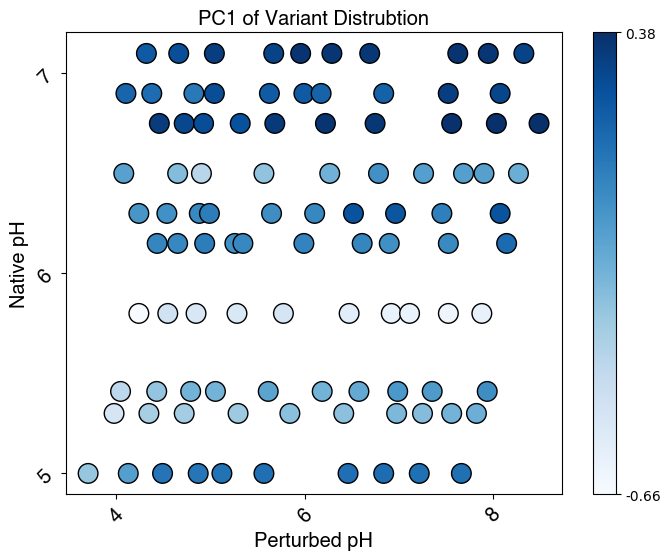

<Axes: title={'center': 'PC1 of Variant Distrubtion'}, xlabel='Perturbed pH', ylabel='Native pH'>

In [137]:
##############################################################################
##  Normalize narG expression levels, only consider T9 CHL+ which is a proxy for T0

nar_rel_exp_chl_pos_t9 = nar_exp_chl_pos_t9 / np.sum(nar_exp_chl_pos_t9, -1)[...,None]

X = nar_rel_exp_chl_pos_t9

X_flat = X.reshape(100, X.shape[2]) 
pca = PCA()
pca_components = pca.fit_transform(X_flat)
X_pc1 = pca_components[:, 0].reshape(10,10)
print(pca.explained_variance_ratio_[0])
plot10(X_pc1, 'PC1 of Variant Distrubtion')

variants, function 0.19641732942646664 p value 0.000999000999000999
native, function 0.2538854499637017 p value 0.000999000999000999
pH, function 0.05816792217392037 p value 0.07892107892107893


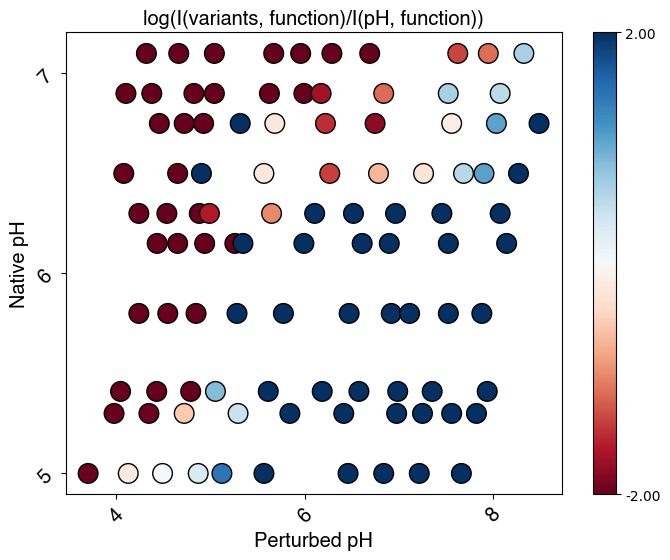

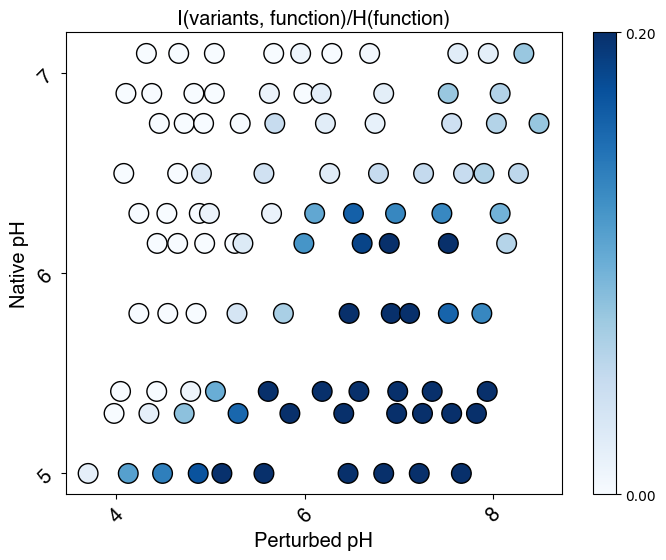

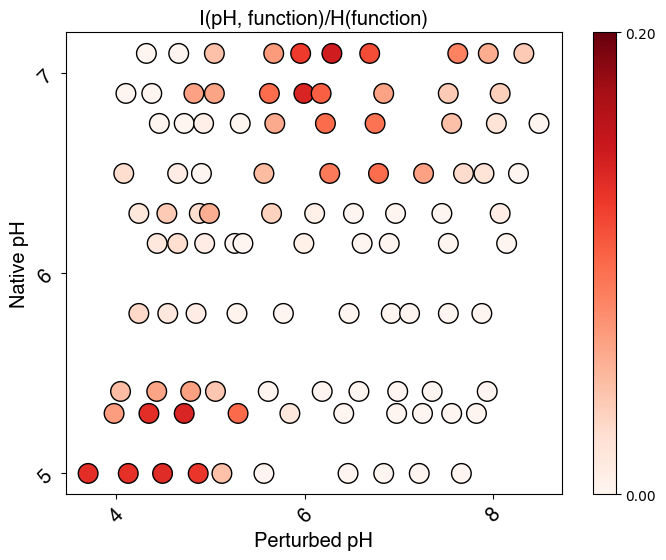

In [138]:
k = 4
print('variants, function', get_info(X_pc1, Y, k = k)[0]/get_entropy(Y, k = k), 'p value', get_info(X_pc1, Y)[2] )
print('native, function', get_info(native_matrix, Y, k = k)[0]/get_entropy(Y, k = k), 'p value', get_info(native_matrix, Y)[2] )
print('pH, function', get_info(pH_matrix, Y, k = k)[0]/get_entropy(Y, k = k), 'p value', get_info(pH_matrix, Y)[2] )

I_pH_r = normalized_info_2D(pH_matrix, Y, neighborhood_size = 30, k = k)[0]
I_var_r = normalized_info_2D(X_pc1, Y, neighborhood_size = 30, k = k)[0]
I_nat_r = normalized_info_2D(native_matrix, Y, neighborhood_size = 30, k = k)[0]

H = get_entropy(Y)
plot10(np.log(I_var_r / (I_pH_r + 0.0001) + 0.0001), 'log(I(variants, function)/I(pH, function))', vmin = -2, vmax = 2, cmap = 'RdBu')
plot10(I_var_r/H, 'I(variants, function)/H(function)', vmin = 0, vmax = 0.2)
plot10(I_pH_r/H, 'I(pH, function)/H(function)', vmin = 0, vmax = 0.2, cmap = 'Reds')

info_ratio = np.log(I_var_r / (I_pH_r + 0.0001) + 0.0001)


### PART 4: Perform regression

NAR Positive Region Coefficients: [-0.02333126  0.          0.          0.          0.         -0.37174099
  1.62284507 -0.        ]
NAR Positive Region Intercept: 1.0755783933390046
NAR Negative Region Coefficients: [ 0.          0.          0.         -0.          0.         -2.261487
  0.89110599 -0.03783383]
NAR Negative Region Intercept: 0.8798213231747306


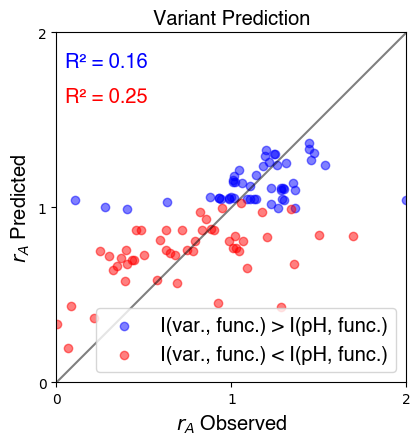

In [140]:

X_nar_flat = X.reshape(100, X.shape[2]) 
y_nar_flat = Y.flatten()                    

ALPHA = 0.001

M = info_ratio

# Create masks based on the sign of M
positive_mask = M > 0
negative_mask = M <= 0

# Get indices for positive and negative regions
positive_indices = np.where(positive_mask)
negative_indices = np.where(negative_mask)

# Extract positive region data
X_pos = X[positive_indices[0], positive_indices[1], :]  
Y_pos = Y[positive_indices[0], positive_indices[1]]  

# Extract negative region data
X_neg= X[negative_indices[0], negative_indices[1], :]  
Y_neg = Y[negative_indices[0], negative_indices[1]]  

# Fit models for positive and negative regions
clf_pos = Lasso(alpha=ALPHA)
clf_pos.fit(X_pos, Y_pos)

clf_neg = Lasso(alpha=ALPHA) 
clf_neg.fit(X_neg, Y_neg)

print("NAR Positive Region Coefficients:", clf_pos.coef_)
print("NAR Positive Region Intercept:", clf_pos.intercept_)
print("NAR Negative Region Coefficients:", clf_neg.coef_)
print("NAR Negative Region Intercept:", clf_neg.intercept_)

pred_pos = clf_pos.predict(X_pos)
pred_neg = clf_neg.predict(X_neg)
obs_pos = Y_pos
obs_neg = Y_neg

r2_nar_positive = r2_score(Y_pos, pred_pos)
r2_nar_negative = r2_score(Y_neg, pred_neg)


# Create a wide figure (10 inches wide, 5 tall)
fig = plt.figure(figsize=(10, 5))

# Add a square axes centered in the figure
# [left, bottom, width, height] in figure fraction coordinates
# We want a square (5/10 = 0.5 width), centered horizontally
ax1 = fig.add_axes([0.5, 0.15, 0.5, 0.7])  # left=0.25, width=0.5 → centered

# Now plot your data on ax1 (same as before)
nar_scale = 10
x = np.linspace(0, nar_scale, 10)
y = np.linspace(0, nar_scale, 10)

ax1.scatter(obs_pos, pred_pos, color='blue', alpha=0.5, label='I(var., func.) > I(pH, func.)')
ax1.scatter(obs_neg, pred_neg, color='red', alpha=0.5, label='I(var., func.) < I(pH, func.)')

ax1.plot(x, y, color='black', alpha=0.5)
ax1.text(0.05, 1.8, f'R² = {r2_nar_positive:.2f}', color='blue', fontsize='x-large', fontname='Helvetica')
ax1.text(0.05, 1.6, f'R² = {r2_nar_negative:.2f}', color='red', fontsize='x-large', fontname='Helvetica')

ax1.set_xlabel('$r_A$ Observed', fontsize='x-large', fontname='Helvetica')
ax1.set_ylabel('$r_A$ Predicted', fontsize='x-large', fontname='Helvetica')
ax1.set_xticks([0, 1, 2])
ax1.set_yticks([0, 1, 2])
ax1.set_xlim(0, 2)
ax1.set_ylim(0, 2)
ax1.set_aspect('equal', adjustable='box')  # Ensures square aspect ratio
ax1.set_title('Variant Prediction', fontsize='x-large', fontname='Helvetica')
ax1.legend(prop={'family': 'Helvetica', 'size': 'x-large'})

plt.show()